# Train MSE Model

In [1]:
from loaders import *
from pipeline import *

train_loader, val_loader, test_loader = get_loaders(speech_dirs=["dev-clean", "test-clean"],
                                                    noise_dir="./wham_noise//wham_noise",
                                                    batch_size=8,
                                                    padding_strategy=None)

sample_batch = next(iter(val_loader))
mixed_waveforms, speech_waveforms = sample_batch

In [2]:
import lightning as L
import torchaudio

encoder_attributes= dict(in_channels=2,
                        out_channels = [4, 8, 16, 32, 32, 64], 
                        kernel_sizes = [7, 5, 5, 3, 3, 3],
                        use_mobile = False,
                        act_func = nn.ReLU(),
                        do_bn = [True, True, True],
                        do_sc = [False, False, True],
                        dp = [0.2, 0.2],
                        num_blocks = 6)




decoder_attributes = dict(in_channels=64, 
                        out_channels = [64, 32, 32,16, 8, 1], 
                        kernel_sizes = [3, 3, 3,  5, 5, 7],
                        use_mobile = False,
                        act_func =nn.ReLU(),
                        do_bn = [True, True, True],
                        do_sc = [False, False, True], 
                        dp = [0.3, 0.4, 0.4],
                        num_blocks = 6)

stft_attributes = dict(n_fft = 2048, 
                    hop_length=112,
                    win_length=128,
                    window_fn=torch.hann_window, 
                    center=False,
                    normalized=False)

model_attributes = dict(
                    hidden_gru = 512,
                    encoder_parameters = encoder_attributes,
                    decoder_parameters = decoder_attributes)


input_signal_size = mixed_waveforms.shape[-1]

In [6]:
# Config 2

encoder_attributes= dict(in_channels=2,
                        out_channels = [4, 16], 
                        kernel_sizes = [5, 3],
                        use_mobile = False,
                        act_func = nn.ReLU(),
                        do_bn = [True, True],
                        do_sc = [True, True],
                        dp = [0.2, 0.2],
                        num_blocks = 2)




decoder_attributes = dict(in_channels=16, 
                        out_channels = [8, 1], 
                        kernel_sizes = [5, 3],
                        use_mobile = False,
                        act_func =nn.ReLU(),
                        do_bn = [True, True],
                        do_sc = [True, True], 
                        dp = [0.2, 0.2],
                        num_blocks = 2)

stft_attributes = dict(n_fft = 2048, 
                    hop_length=112,
                    win_length=128,
                    window_fn=torch.hann_window, 
                    center=True,
                    normalized=False,
                    return_complex=True)

model_attributes = dict(
                    hidden_gru = 256,
                    encoder_parameters = encoder_attributes,
                    decoder_parameters = decoder_attributes)


input_signal_size = mixed_waveforms.shape[-1]

In [7]:
from lightning.pytorch.callbacks import ModelCheckpoint
import torch.optim as optim
import torch.nn.functional as F
import librosa

class SpectrogramLightningModel(L.LightningModule):
    def __init__(self, model_attributes, stft_attributes, input_signal_size = input_signal_size):
        super().__init__()
        
        
        self.stft = torchaudio.transforms.Spectrogram(**stft_attributes)
        dummy = torch.rand(1, 1, input_signal_size)
        dummy_shape = self.stft(dummy).shape[-2:]
        self.model = DenoisingModel(input_shape = dummy_shape,**model_attributes)
        self.mse = nn.MSELoss()
        
    def configure_optimizers(self):
        
        optimizer = optim.Adam(self.model.parameters(), lr=1.41e-4)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.999)
        
        lr_scheduler_config = {
            "scheduler": scheduler,

            "interval": "epoch",

            "frequency": 1,
        }

        return [optimizer], [lr_scheduler_config]
    
    def configure_callbacks(self):
        checkpoint_callback = ModelCheckpoint(
            monitor="valid_loss",
            mode="max",
            save_top_k=1,
            filename="best-checkpoint-{epoch:02d}-{valid_loss:.2f}",
            save_last=True,
            every_n_epochs=1
        )
        return [checkpoint_callback]
    
    def training_step(self, batch):
        return self._step(batch, "train")

    def validation_step(self, batch):
        return self._step(batch, "valid")
    
    
    @staticmethod
    def spec_pad(model_output, spectrogram):

        if spectrogram.size(2) >= spectrogram.size(2) and spectrogram.size(3) >= spectrogram.size(3):
            padding_rows = spectrogram.size(2) - model_output.size(2)  
            padding_cols = spectrogram.size(3) - model_output.size(3)
            out = F.pad(model_output, (0, padding_cols, 0, padding_rows))  

        else:
            out = model_output[:, :, :spectrogram.shape[-2], :spectrogram.shape[-1]]
             
        return out
    

    def forward(self, mixed_waveforms, speech_waveforms):

        stft_clean = self.stft(speech_waveforms).to(self.device)
        stft_mixed = self.stft(mixed_waveforms).to(self.device)
        output = self.model(stft_mixed)
        
        if output.shape != stft_clean.shape:
            output = self.spec_pad(output, stft_clean)

        return output, stft_clean
    

    def invoke(self, noisy):
        with torch.no_grad():
            output = self.model(noisy)

        return output


    def _step(self, batch, kind):

        mixed_waveforms, speech_waveforms = batch
        output, stft_clean = self.forward(mixed_waveforms, speech_waveforms)
        
        loss = self.mse(output, stft_clean)
        
        metrics = {
            f"{kind}_loss": loss,
        }
        self.log_dict(
            metrics,
            prog_bar=True,
            logger=True,
            on_step=False,
            on_epoch=True)

        return loss

In [8]:
model = SpectrogramLightningModel(model_attributes=model_attributes,
                           stft_attributes=stft_attributes,
                           input_signal_size = input_signal_size)
trainer = L.Trainer(accelerator="auto",max_epochs=100,logger=True)                  
                            
                            

trainer.fit(model, train_loader, val_loader)

/home/ysergaev/CV/venv/lib/python3.12/site-packages/torchaudio/transforms/_transforms.py:94: UserWarning: `return_complex` argument is now deprecated and is not effective.`torchaudio.transforms.Spectrogram(power=None)` always returns a tensor with complex dtype. Please remove the argument in the function call.
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/ysergaev/CV/venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:75: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
The following callb

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/ysergaev/CV/venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/home/ysergaev/CV/venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

In [9]:
re = torchaudio.transforms.Spectrogram(n_fft = 2048, hop_length=112,
                    win_length=128,
                    window_fn=torch.hann_window, 
                    center=False,
                    onesided=True, 
                    normalized=False)(mixed_waveforms.cpu())
re.shape


torch.Size([8, 2, 1025, 1125])

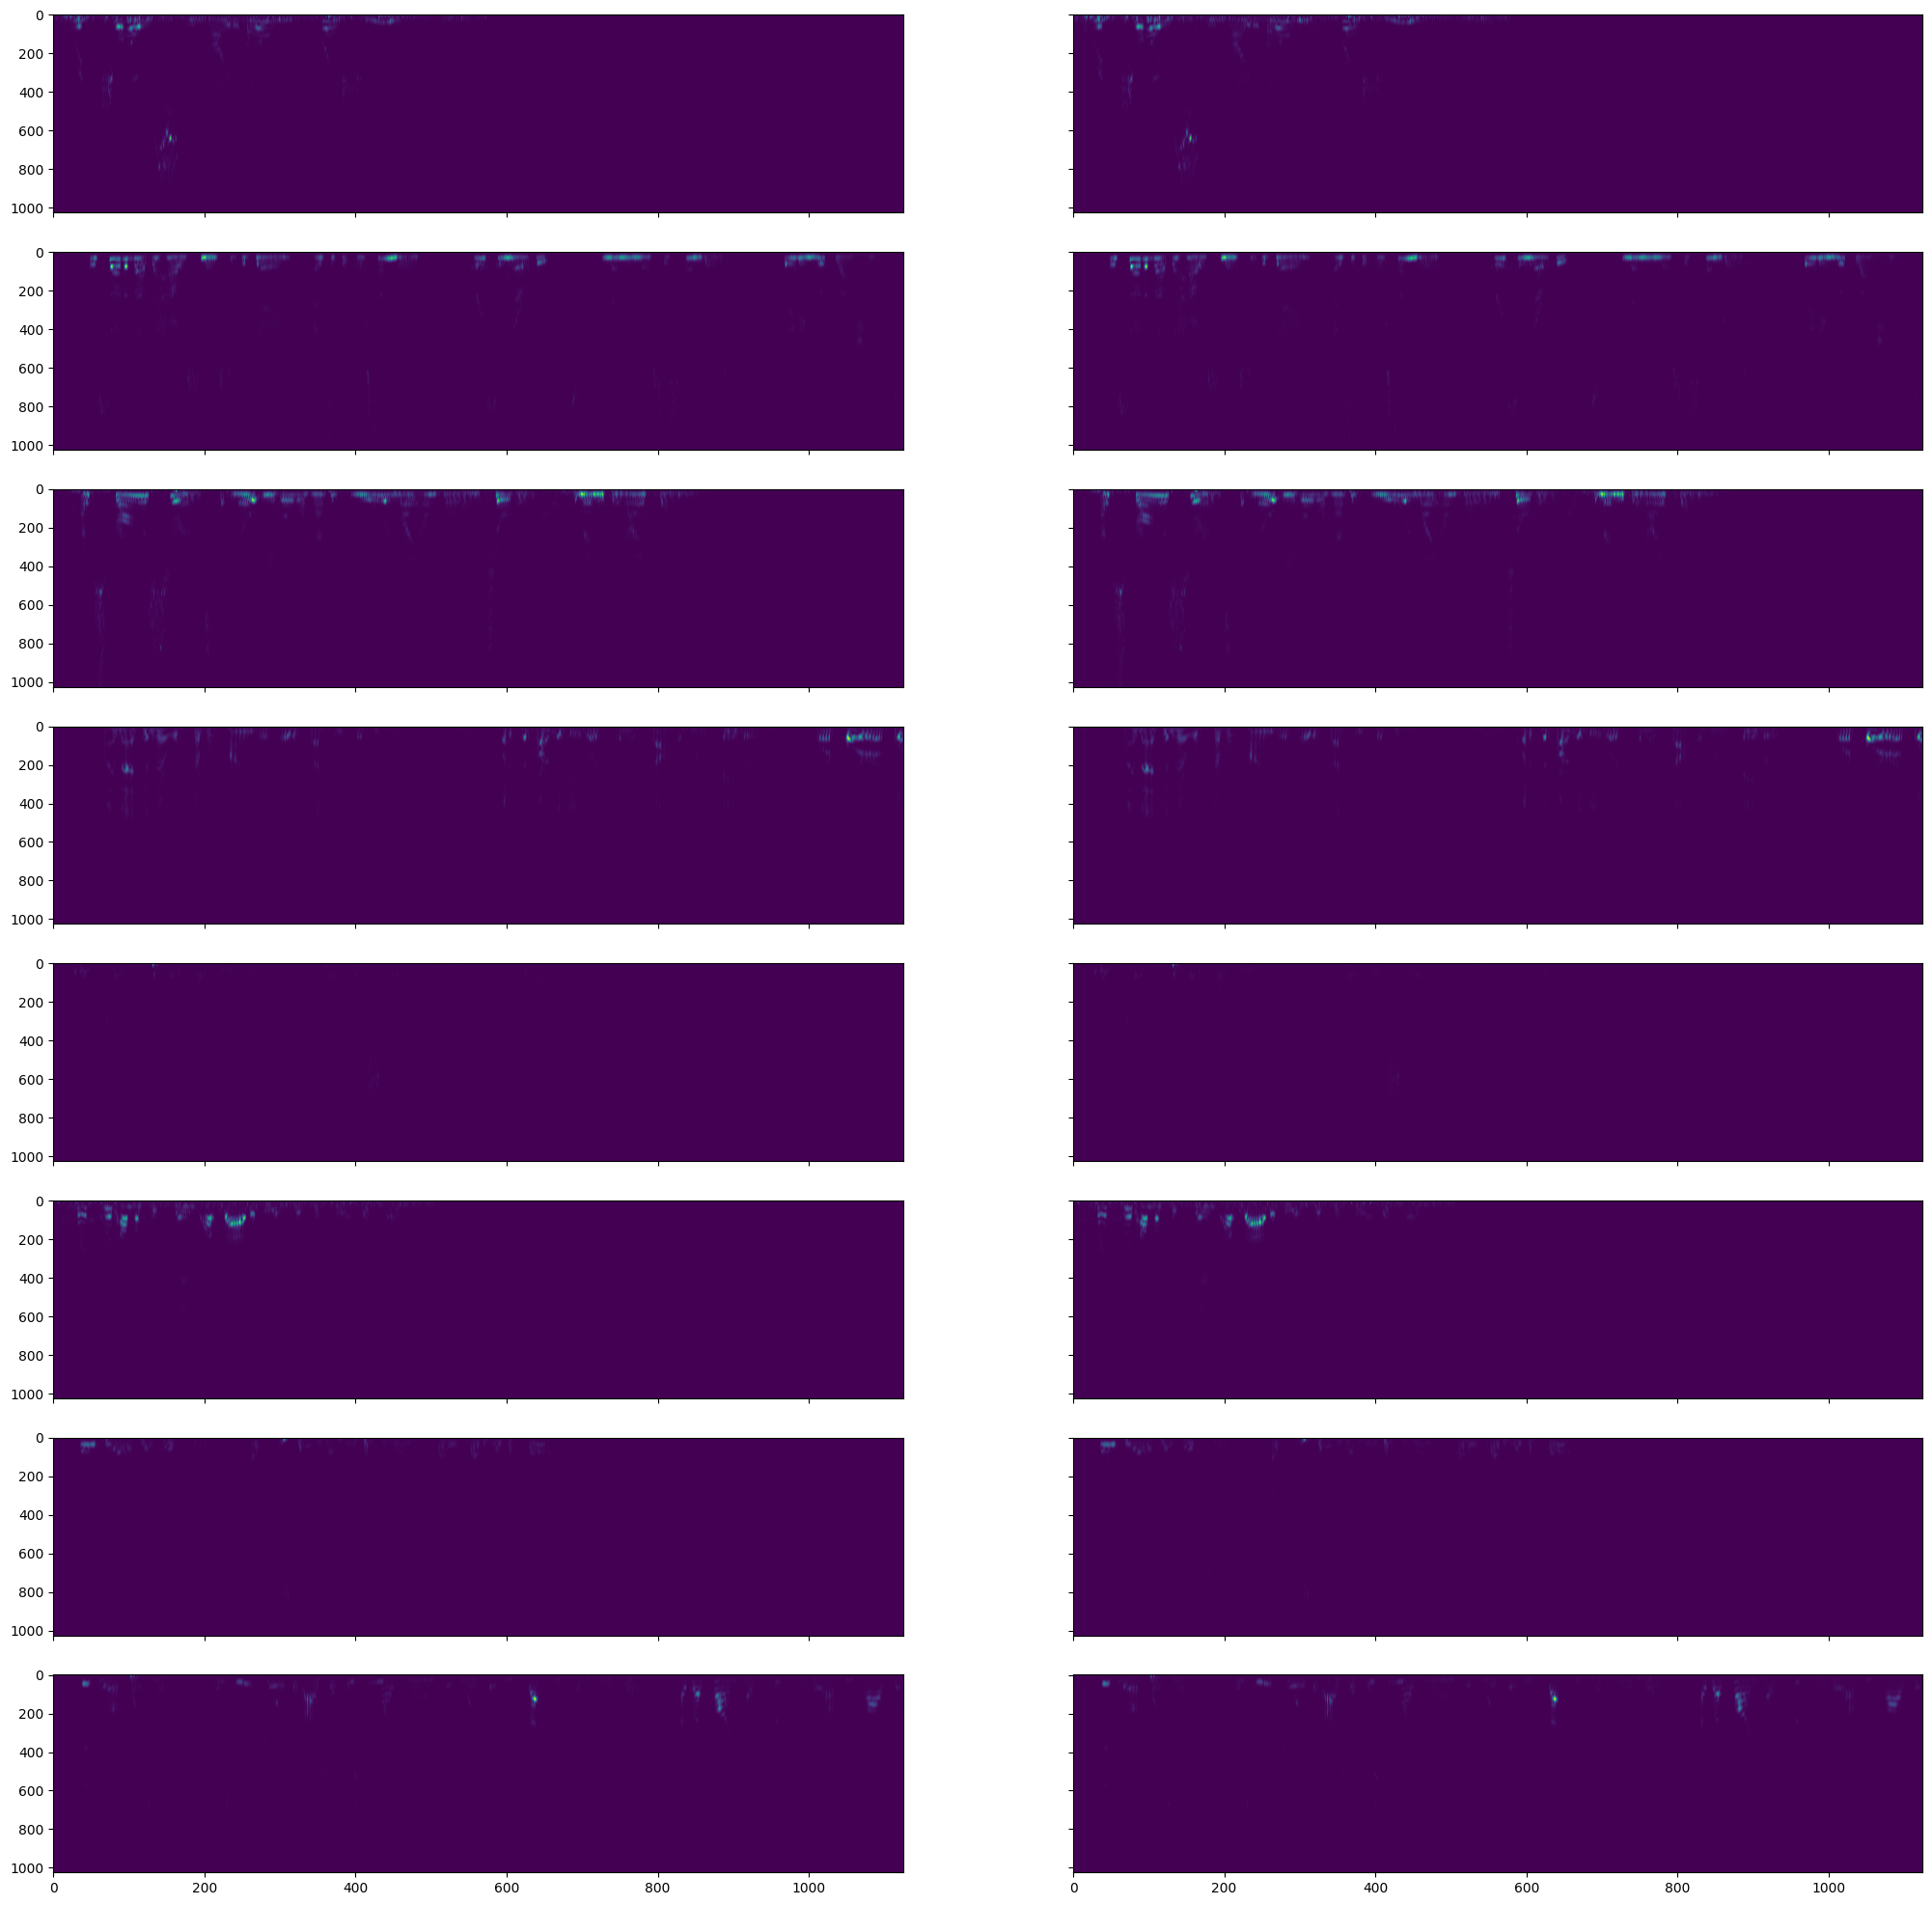

In [10]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(8, 2, figsize=(25, 25), sharex=True, sharey=True)
for i in range(8):
   
    axes[i, 0].imshow(re[i, 0, :, :].numpy(), aspect='auto', cmap='viridis')
    axes[i, 1].imshow(re[i, 1, :, :].numpy(), aspect='auto', cmap='viridis')


In [5]:
model = SpectrogramLightningModel.load_from_checkpoint('/home/ysergaev/CV/Project/lightning_logs/version_22/checkpoints/best-checkpoint-epoch=65-valid_loss=11.80.ckpt',
                                             attributes = model_attributes)

batch = next(iter(train_loader))
mixed_waveforms, speech_waveforms = batch
mixed_waveforms = mixed_waveforms.to('cuda')
speech_waveforms = speech_waveforms.to('cuda')

batch = mixed_waveforms, speech_waveforms
loss = model._step(batch, 'train')

cleaned = model.invoke(mixed_waveforms)

/home/ysergaev/CV/venv/lib/python3.12/site-packages/lightning/pytorch/core/module.py:445: You are trying to `self.log()` but the `self.trainer` reference is not registered on the model yet. This is most likely because the model hasn't been passed to the `Trainer`


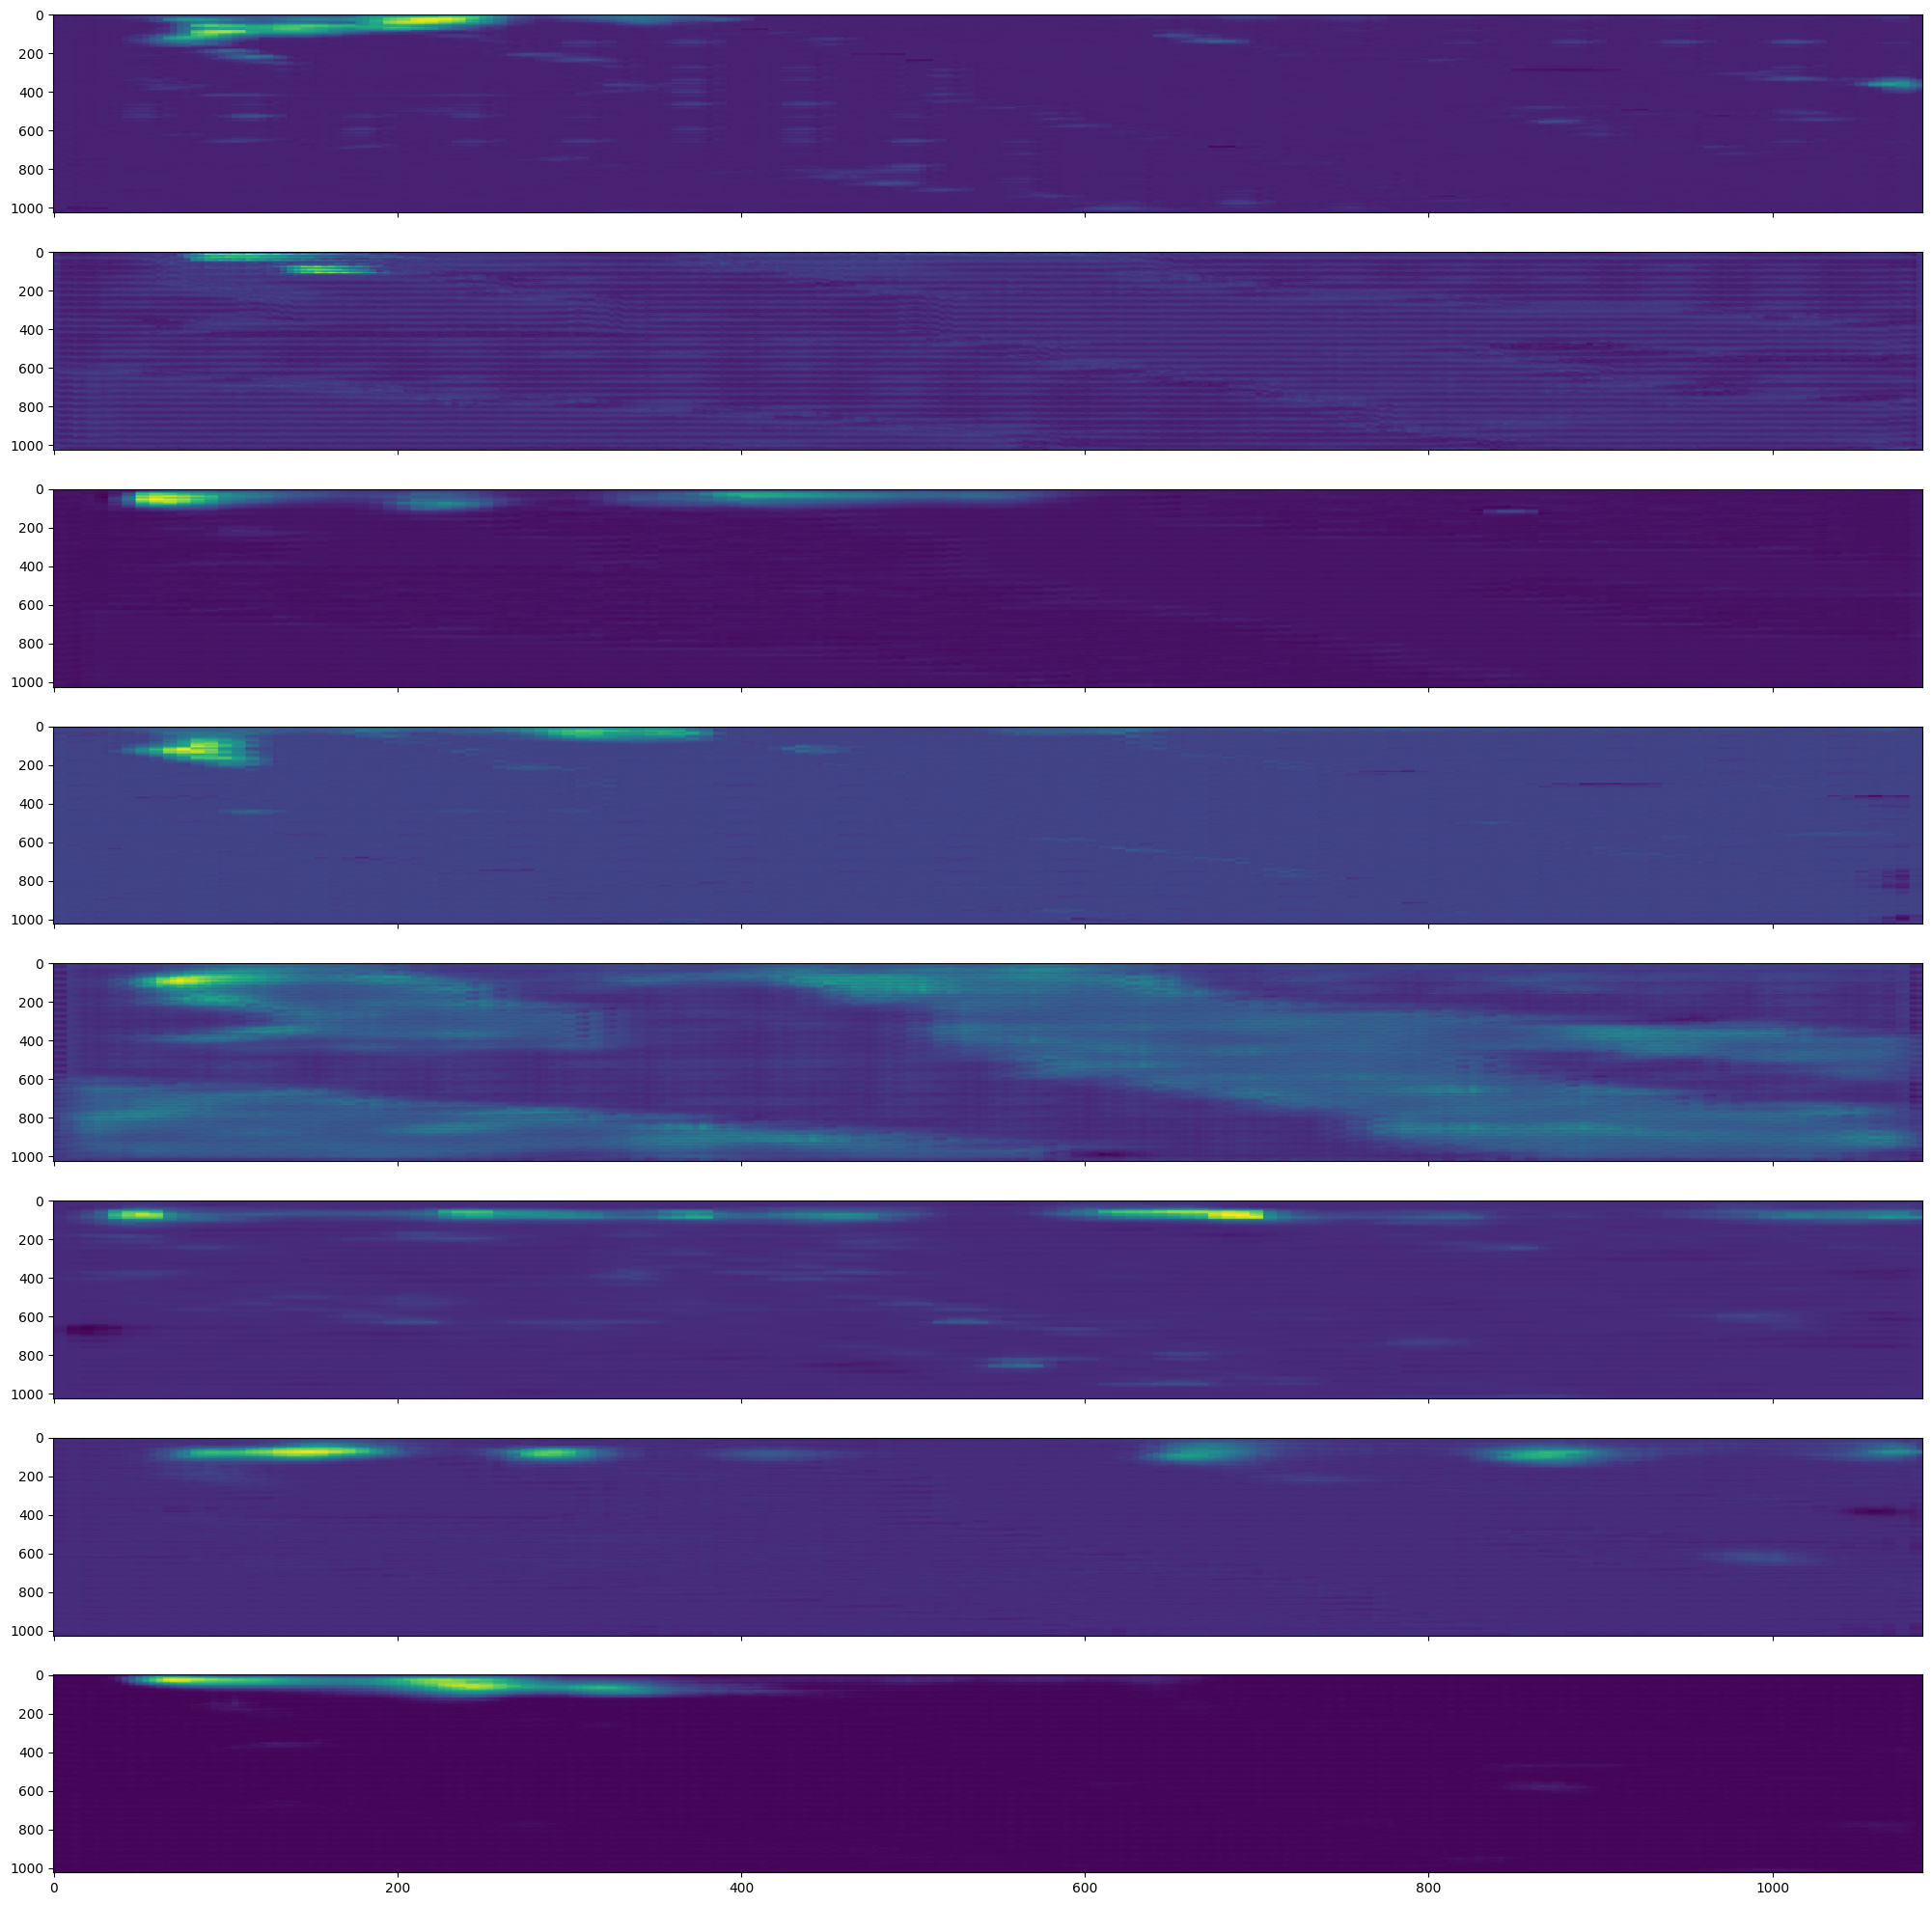

In [8]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(8, 1, figsize=(25, 25), sharex=True, sharey=True)
for i in range(8):
   
    axes[i].imshow(cleaned[i, 0, :, :].cpu().numpy(), aspect='auto', cmap='viridis')


In [12]:
from IPython.display import Audio 

s2 = librosa.istft(cleaned.cpu().numpy(), n_fft=model.model.stft.n_fft,hop_length=model.model.stft.hop_length,
                    win_length=model.model.stft.win_length, center=model.model.stft.center)

for i, cleaned_batch in enumerate(s2):
    print(f"--------------------\nsample {i} from batch")
    print(f"Input audio {i + 1}:")
    display(Audio(cleaned_batch, rate=train_loader.dataset.sample_rate))

--------------------
sample 0 from batch
Input audio 1:


--------------------
sample 1 from batch
Input audio 2:


--------------------
sample 2 from batch
Input audio 3:


--------------------
sample 3 from batch
Input audio 4:


--------------------
sample 4 from batch
Input audio 5:


--------------------
sample 5 from batch
Input audio 6:


--------------------
sample 6 from batch
Input audio 7:


--------------------
sample 7 from batch
Input audio 8:


# Train Mask Model

In [1]:
from loaders import *
from pipeline import *

train_loader, val_loader, test_loader = get_loaders(speech_dirs=["dev-clean", "test-clean"],
                                                    noise_dir="./wham_noise//wham_noise",
                                                    batch_size=8,
                                                    padding_strategy=None)

sample_batch = next(iter(val_loader))
mixed_waveforms, speech_waveforms = sample_batch

In [5]:
import lightning as L
import torchaudio

encoder_attributes= dict(in_channels=1,
                        out_channels = [4, 16], 
                        kernel_sizes = [5, 3],
                        use_mobile = False,
                        act_func = nn.Tanh(),
                        do_bn = [True, True],
                        do_sc = [True, True],
                        dp = [0.2, 0.2],
                        num_blocks = 2)




decoder_attributes = dict(in_channels=16, 
                        out_channels = [8, 1], 
                        kernel_sizes = [5, 3],
                        use_mobile = False,
                        act_func =nn.Tanh(),
                        do_bn = [True, True],
                        do_sc = [True, True], 
                        dp = [0.2, 0.2],
                        num_blocks = 2)

stft_attributes = dict(n_fft = 2048, 
                    hop_length=112,
                    win_length=128,
                    window_fn=torch.hann_window, 
                    center=True,
                    normalized=False)

model_attributes = dict(
                    hidden_gru = 256,
                    encoder_parameters = encoder_attributes,
                    decoder_parameters = decoder_attributes)


input_signal_size = mixed_waveforms.shape[-1]

In [6]:
from lightning.pytorch.callbacks import ModelCheckpoint
import torch.optim as optim
import torch.nn.functional as F


class MaskLightningModel(L.LightningModule):
    def __init__(self, model_attributes, stft_attributes, input_signal_size):
        super().__init__()
        
        self.stft = torchaudio.transforms.Spectrogram(**stft_attributes)
        
        dummy = torch.rand(1, 1, input_signal_size)
        dummy_shape = self.stft(dummy).shape[-2:]
        self.model = DenoisingModel(input_shape = dummy_shape,**model_attributes)
        self.sdr = SDR() #SiSDRLoss()
        self.istft = torchaudio.transforms.InverseSpectrogram(**stft_attributes)

        
    def configure_optimizers(self):
        
        optimizer = optim.Adam(self.model.parameters(), lr=1.41e-4)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.999)
        
        lr_scheduler_config = {
            "scheduler": scheduler,

            "interval": "epoch",

            "frequency": 1,
        }

        return [optimizer], [lr_scheduler_config]
    
    def configure_callbacks(self):
        checkpoint_callback = ModelCheckpoint(
            monitor="valid_loss",
            mode="max",
            save_top_k=1,
            filename="best-checkpoint-{epoch:02d}-{valid_loss:.2f}",
            save_last=True,
            every_n_epochs=1
        )
        return [checkpoint_callback]
    
    def training_step(self, batch):
        return self._step(batch, "train")

    def validation_step(self, batch):
        return self._step(batch, "valid")
    
    @staticmethod
    def spec_pad(model_output, spectrogram):

        if spectrogram.size(2) >= spectrogram.size(2) and spectrogram.size(3) >= spectrogram.size(3):
            padding_rows = spectrogram.size(2) - model_output.size(2)  
            padding_cols = spectrogram.size(3) - model_output.size(3)
            out = F.pad(model_output, (0, padding_cols, 0, padding_rows))  

        else:
            out = model_output[:, :, :spectrogram.shape[-2], :spectrogram.shape[-1]]
             

        return out
    
    @staticmethod
    def denoize_waveform_pad(denoized_wf, clear_wf):
        if clear_wf.shape[-1] > denoized_wf.shape[-1]:
            diff = clear_wf.shape[-1] - denoized_wf.shape[-1]
            out = F.pad(denoized_wf, pad=(0, diff))
            
        else:
            out = denoized_wf[:, :, :clear_wf.shape[-1]]
        
        return out
        

    def forward(self, mixed_waveforms):
        
        
        spectrogram = self.stft(mixed_waveforms)
        output = self.model(spectrogram)
        
        
        if output.shape != spectrogram.shape:
            output = self.spec_pad(output, spectrogram)

        
        masked = output * spectrogram
        masked = torch.complex(masked, torch.zeros_like(masked))
        denoised = self.istft(masked)
        pad_for_audio = self.denoize_waveform_pad(denoised, mixed_waveforms)
        return pad_for_audio
    

    def _step(self, batch, kind):

        mixed_waveforms, speech_waveforms = batch
        mixed_waveforms = mixed_waveforms[:, 0, None, :]

        output = self.forward(mixed_waveforms)
        
        loss = self.sdr(speech_waveforms,mixed_waveforms, output)
        
        metrics = {
            f"{kind}_loss": loss,
        }
        self.log_dict(
            metrics,
            prog_bar=True,
            logger=True,
            on_step=True,
            on_epoch=True)

        return loss

In [7]:
model = MaskLightningModel(model_attributes=model_attributes,
                           stft_attributes=stft_attributes,
                           input_signal_size = input_signal_size)
trainer = L.Trainer(accelerator="auto",max_epochs=100,logger=True)                  
                            
                            

trainer.fit(model, train_loader, val_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type               | Params | Mode 
-----------------------------------------------------
0 | stft  | Spectrogram        | 0      | train
1 | model | DenoisingModel     | 10.0 M | train
2 | sdr   | SDR                | 0      | train
3 | istft | InverseSpectrogram | 0      | train
-----------------------------------------------------
10.0 M    Trainable params
0         Non-trainable params
10.0 M    Total params
39.864    Total estimated model params size (MB)
42        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/ysergaev/CV/venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/home/ysergaev/CV/venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined